# Working with Large Datasets in Pandas

It is no lie that 'Data is the new Oil', but the amount of data produced every day is mind-boggling. As of 2026, approximately **474 Million Terabytes** of data are generated daily. And it is not surprising that,
In the last two years alone, the astonishing 90% of the world’s data has been created.

To be able to handle and engineer such a vast amount of data is **power**.

In This Tutorial we will cover the following topics:
- Loading datasets into Google Colab.
- Fastening Data Loading processes with *pandas.dataframe*
- Memory saving with pandas(Chunking)
- Loading datasets into intermediate file formats.
- Fastening Data Loading processes with other libraries.



 ## Dataset  

We will be using a relatively large dataset from Kaggle.

https://www.kaggle.com/datasets/nawazh/us-accidents-2020-2023/

In [6]:
import sys
print(sys.version)

3.14.2 (tags/v3.14.2:df79316, Dec  5 2025, 17:18:21) [MSC v.1944 64 bit (AMD64)]


In [1]:
from pathlib import Path
import pandas as pd

# Load the dataset from the path you added.
filepath = Path(r"G:\ML Course\Week 5\US_Accidents_March23.csv")

if not filepath.exists():
    raise FileNotFoundError(f"Dataset not found at: {filepath}")

print("Path to dataset:", filepath)

# Read a small preview to confirm the file loads properly.
df = pd.read_csv(filepath, nrows=5)
print(df.head())

Path to dataset: G:\ML Course\Week 5\US_Accidents_March23.csv
          ID   Source  Severity           Start_Time             End_Time  \
0  A-7279975  Source1         2  2020-01-01 00:01:00  2020-01-01 01:33:25   
1  A-7279974  Source1         2  2020-01-01 00:02:00  2020-01-01 00:34:29   
2  A-7279798  Source1         2  2020-01-01 00:03:00  2020-01-01 00:54:28   
3  A-7279495  Source1         3  2020-01-01 00:05:48  2020-01-01 00:35:10   
4  A-1674852  Source2         2  2020-01-01 00:07:41  2020-01-01 00:52:37   

   Start_Lat   Start_Lng    End_Lat     End_Lng  Distance(mi)  ... Roundabout  \
0  34.160675 -118.829524  34.160675 -118.829524         0.000  ...      False   
1  34.426305 -117.572553  34.426305 -117.572553         0.000  ...      False   
2  38.811739 -121.300396  38.811739 -121.300396         0.000  ...      False   
3  41.761780  -87.866720  41.761340  -87.867430         0.048  ...      False   
4  47.463398 -122.293129        NaN         NaN         0.000  ...    

### Using `pathlib` for Path Management

In modern Python, `pathlib` is the preferred way to handle file system paths. Unlike string-based path manipulation, `pathlib` treats paths as objects, providing several advantages:

- **Readability**: Operations like joining paths use the `/` operator.
- **Functionality**: You can easily extract filenames, extensions, or parent directories without complex string splitting.
- **Cross-Platform**: It automatically handles the differences between Windows (`\`) and Unix/Linux (`/`) path separators.

In our code above, we used `Path(path, 'US_Accidents_March23.csv')` to create a robust pointer to our data file.

In [2]:
from pathlib import Path


print(f"Full path: {filepath}")
print(f"File name: {filepath.name}")
print(f"File stem (no extension): {filepath.stem}")
print(f"File extension: {filepath.suffix}")
print(f"Parent directory: {filepath.parent}")

Full path: G:\ML Course\Week 5\US_Accidents_March23.csv
File name: US_Accidents_March23.csv
File stem (no extension): US_Accidents_March23
File extension: .csv
Parent directory: G:\ML Course\Week 5


For *most data analysis tasks*, the python ***pandas*** package is good enough. We can do all sorts of data manipulation with it, and it is compatible for building ML models.

But, as our data gets bigger, bigger than what can fit in the available  RAM, **pandas is not sufficient**.


We could use Spark or Hadoop to solve this, but these cannot actually provide/work in python environments. This will stop us from using numpy, sklearn, pandas, tensorflow, and all the commonly used Python libraries for ML.



In [3]:
%%time

df=pd.read_csv(filepath)

CPU times: total: 21.7 s
Wall time: 21.8 s


In [4]:
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-7279975,Source1,2,2020-01-01 00:01:00,2020-01-01 01:33:25,34.160675,-118.829524,34.160675,-118.829524,0.000,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-7279974,Source1,2,2020-01-01 00:02:00,2020-01-01 00:34:29,34.426305,-117.572553,34.426305,-117.572553,0.000,...,False,False,False,False,True,False,Night,Night,Night,Night
2,A-7279798,Source1,2,2020-01-01 00:03:00,2020-01-01 00:54:28,38.811739,-121.300396,38.811739,-121.300396,0.000,...,False,False,False,False,False,False,Night,Night,Night,Night
3,A-7279495,Source1,3,2020-01-01 00:05:48,2020-01-01 00:35:10,41.761780,-87.866720,41.761340,-87.867430,0.048,...,False,False,False,False,False,False,Night,Night,Night,Night
4,A-1674852,Source2,2,2020-01-01 00:07:41,2020-01-01 00:52:37,47.463398,-122.293129,NaN,NaN,0.000,...,False,False,False,False,False,False,Night,Night,Night,Night


In [5]:
df.shape

(4751751, 46)

In [6]:
df.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 4751751 entries, 0 to 4751750
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     str    
 1   Source                 str    
 2   Severity               int64  
 3   Start_Time             str    
 4   End_Time               str    
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            str    
 11  Street                 str    
 12  City                   str    
 13  County                 str    
 14  State                  str    
 15  Zipcode                str    
 16  Country                str    
 17  Timezone               str    
 18  Airport_Code           str    
 19  Weather_Timestamp      str    
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)            float6

Pandas took approximately 40-50 seconds to process/load our approximately 5.8GB of dataset into its dataframe. This does not sound so efficient when working with with even larger datasets. There's various ways we can reduce/change this.

I have mentioned how you can load your dataset faster with other packages in python such as dask, pyspark towards the end of this article.  

## Pandas default memory allocation

By default, pandas infers the datatypes of the columns of our dataset in not the most convenient way. Rather, due to its conservative nature, it often results in unnecessary large memory usage for pandas dataframe especially for text data columns with relatively few unique values. One of the ways you can use pandas to scale your data into memory is by lossless compression which I have shown below.

We can pre-define optimal datatypes for our columns based on prior knowledge of the dataset or sample inspection. This way we can store larger datasets in memory.


* You can find information on the dataset I have used [here.](https://smoosavi.org/datasets/us_accidents)

In [8]:
df.memory_usage(deep= True)
#shows how much bytes each column is using 

Index                          132
ID                       275123541
Source                   266098056
Severity                  38014008
Start_Time               323119068
End_Time                 330360156
Start_Lat                 38014008
Start_Lng                 38014008
End_Lat                   38014008
End_Lng                   38014008
Distance(mi)              38014008
Description              593407169
Street                   284972132
City                     274552391
County                   271451618
State                    242339301
Zipcode                  263857319
Country                  242339301
Timezone                 280495949
Airport_Code             251484207
Weather_Timestamp        320108100
Temperature(F)            38014008
Wind_Chill(F)             38014008
Humidity(%)               38014008
Pressure(in)              38014008
Visibility(mi)            38014008
Wind_Direction           242114646
Wind_Speed(mph)           38014008
Precipitation(in)   

In [9]:
274552391/1024/1024

261.83356380462646

Notice how the columns with high cardinality take up more space, than other. Most columns here are good candidates for converting to **categorical** data types. *With a Categorical, we store each unique name once and use space-efficient integers to know which specific name is used in each row.*

Let me redefine a pandas dataframe by explicitly providing datatypes for my columns or **changing datatypes for certain columns**. 

In [10]:
cat = ['Source', 'Street', 'City', 'County', 'State','Zipcode','Country', 'Timezone', 'Airport_Code','Wind_Direction','Weather_Condition', 'Sunrise_Sunset','Civil_Twilight','Nautical_Twilight','Astronomical_Twilight']


df[cat] = df[cat].astype("category")

In [11]:
df.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 4751751 entries, 0 to 4751750
Data columns (total 46 columns):
 #   Column                 Dtype   
---  ------                 -----   
 0   ID                     str     
 1   Source                 category
 2   Severity               int64   
 3   Start_Time             str     
 4   End_Time               str     
 5   Start_Lat              float64 
 6   Start_Lng              float64 
 7   End_Lat                float64 
 8   End_Lng                float64 
 9   Distance(mi)           float64 
 10  Description            str     
 11  Street                 category
 12  City                   category
 13  County                 category
 14  State                  category
 15  Zipcode                category
 16  Country                category
 17  Timezone               category
 18  Airport_Code           category
 19  Weather_Timestamp      str     
 20  Temperature(F)         float64 
 21  Wind_Chill(F)          float64 
 22  Humid

### 5.8 GB to 2.4 GB 🤯

In [12]:
df.memory_usage(deep = True)

Index                          132
ID                       275123541
Source                     4751919
Severity                  38014008
Start_Time               323119068
End_Time                 330360156
Start_Lat                 38014008
Start_Lng                 38014008
End_Lat                   38014008
End_Lng                   38014008
Distance(mi)              38014008
Description              593407169
Street                    35633635
City                      10227439
County                     9604398
State                      4754250
Zipcode                   53675164
Country                    4751802
Timezone                   4751988
Airport_Code               9608919
Weather_Timestamp        320108100
Temperature(F)            38014008
Wind_Chill(F)             38014008
Humidity(%)               38014008
Pressure(in)              38014008
Visibility(mi)            38014008
Wind_Direction             4752676
Wind_Speed(mph)           38014008
Precipitation(in)   

In [13]:
10227439 / 1024 /1024

9.753645896911621

## Saving Time With Datetime Data
If no arguments are specified, date_time will take on an object dtype.
This is not ideal.` object `is a container for not just str, but any column that can’t neatly fit into one data type. It would be arduous and inefficient to work with dates as strings. (It would also be memory-inefficient.)
We will make our date_time columns as datetime objects. (Timestamp)

In [14]:
dtime=['Start_Time' , 'End_Time' ,'Weather_Timestamp']
df[dtime] = df[dtime].apply(pd.to_datetime , format ='mixed')

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4751751 entries, 0 to 4751750
Data columns (total 46 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   ID                     str           
 1   Source                 category      
 2   Severity               int64         
 3   Start_Time             datetime64[us]
 4   End_Time               datetime64[ns]
 5   Start_Lat              float64       
 6   Start_Lng              float64       
 7   End_Lat                float64       
 8   End_Lng                float64       
 9   Distance(mi)           float64       
 10  Description            str           
 11  Street                 category      
 12  City                   category      
 13  County                 category      
 14  State                  category      
 15  Zipcode                category      
 16  Country                category      
 17  Timezone               category      
 18  Airport_Code           category  

As a general rule, Pandas will be far quicker the less it has to interpret your data. In this case, you will see huge speed improvements just by telling Pandas what your time and date data looks like, using the **format parameter**.

You can find the string format codes [here (strftime)](https://strftime.org/), and entering them like this:

`df[dtime] = df[dtime].apply(pd.to_datetime, format='%d/%m/%y %H:%M')`

In [18]:
memeory_used_in_gb = df.memory_usage(deep = True).sum() / 1024 / 1024 / 1024
print(f'Memory used: {memeory_used_in_gb:.2f} GB')

Memory used: 1.59 GB


Using `pd.to_numeric`, We can go a bit further and downcast the numeric columns to their smallest types.

In [19]:
numeric = ['Start_Lat',	'Start_Lng',	'End_Lat',	'End_Lng',	'Distance(mi)', 'Temperature(F)',	'Wind_Chill(F)',	'Humidity(%)',	'Pressure(in)',	'Visibility(mi)','Wind_Speed(mph)',	'Precipitation(in)']


In [20]:
df[numeric].info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 4751751 entries, 0 to 4751750
Data columns (total 12 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Start_Lat          float64
 1   Start_Lng          float64
 2   End_Lat            float64
 3   End_Lng            float64
 4   Distance(mi)       float64
 5   Temperature(F)     float64
 6   Wind_Chill(F)      float64
 7   Humidity(%)        float64
 8   Pressure(in)       float64
 9   Visibility(mi)     float64
 10  Wind_Speed(mph)    float64
 11  Precipitation(in)  float64
dtypes: float64(12)
memory usage: 435.0 MB


In [21]:
df[numeric].head()

,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
0,34.160675,-118.829524,34.160675,-118.829524,0.000,50.0,50.0,59.0,29.98,10.0,6.0,0.0
1,34.426305,-117.572553,34.426305,-117.572553,0.000,37.0,37.0,65.0,26.91,10.0,0.0,0.0
2,38.811739,-121.300396,38.811739,-121.300396,0.000,43.0,43.0,93.0,30.05,7.0,0.0,0.0
3,41.761780,-87.866720,41.761340,-87.867430,0.048,27.0,19.0,81.0,29.16,9.0,8.0,0.0
4,47.463398,-122.293129,NaN,NaN,0.000,53.0,53.0,83.0,29.20,10.0,17.0,0.0


In [25]:
import numpy as np 

integer_datatypes = [np.int8 , np.int16 , np.int32 , np.int64]
float_datatypes = [ np.float16 , np.float32 , np.float64]

for datatype in integer_datatypes:
    min_value = np.iinfo(datatype).min
    max_value = np.iinfo(datatype).max
    print(f'{datatype}: min = {min_value} , max={max_value}' )
    
for datatype in float_datatypes:
    min_value = np.finfo(datatype).min
    max_value = np.finfo(datatype).max
    print(f'{datatype}: min = {min_value} , max={max_value}' )
    

<class 'numpy.int8'>: min = -128 , max=127
<class 'numpy.int16'>: min = -32768 , max=32767
<class 'numpy.int32'>: min = -2147483648 , max=2147483647
<class 'numpy.int64'>: min = -9223372036854775808 , max=9223372036854775807
<class 'numpy.float16'>: min = -65504.0 , max=65504.0
<class 'numpy.float32'>: min = -3.4028234663852886e+38 , max=3.4028234663852886e+38
<class 'numpy.float64'>: min = -1.7976931348623157e+308 , max=1.7976931348623157e+308


In [26]:
numeric

['Start_Lat',
 'Start_Lng',
 'End_Lat',
 'End_Lng',
 'Distance(mi)',
 'Temperature(F)',
 'Wind_Chill(F)',
 'Humidity(%)',
 'Pressure(in)',
 'Visibility(mi)',
 'Wind_Speed(mph)',
 'Precipitation(in)']

In [27]:
df[numeric] = df[numeric].apply(pd.to_numeric, downcast="float")

In [28]:
df[numeric].info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 4751751 entries, 0 to 4751750
Data columns (total 12 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Start_Lat          float32
 1   Start_Lng          float32
 2   End_Lat            float32
 3   End_Lng            float32
 4   Distance(mi)       float32
 5   Temperature(F)     float32
 6   Wind_Chill(F)      float32
 7   Humidity(%)        float32
 8   Pressure(in)       float32
 9   Visibility(mi)     float32
 10  Wind_Speed(mph)    float32
 11  Precipitation(in)  float32
dtypes: float32(12)
memory usage: 217.5 MB


435 Mb to only 217.5 MB . In all, we’ve reduced the in-memory footprint of this dataset to almost 1/5 of its original size.

In [29]:
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-7279975,Source1,2,2020-01-01 00:01:00,2020-01-01 01:33:25,34.160675,-118.829521,34.160675,-118.829521,0.000,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-7279974,Source1,2,2020-01-01 00:02:00,2020-01-01 00:34:29,34.426304,-117.572556,34.426304,-117.572556,0.000,...,False,False,False,False,True,False,Night,Night,Night,Night
2,A-7279798,Source1,2,2020-01-01 00:03:00,2020-01-01 00:54:28,38.811741,-121.300400,38.811741,-121.300400,0.000,...,False,False,False,False,False,False,Night,Night,Night,Night
3,A-7279495,Source1,3,2020-01-01 00:05:48,2020-01-01 00:35:10,41.761780,-87.866722,41.761341,-87.867432,0.048,...,False,False,False,False,False,False,Night,Night,Night,Night
4,A-1674852,Source2,2,2020-01-01 00:07:41,2020-01-01 00:52:37,47.463398,-122.293129,NaN,NaN,0.000,...,False,False,False,False,False,False,Night,Night,Night,Night


### Explicitly providing column datatypes during loading of dataset.

We can pre-define optimal data types of the columns (based on prior knowledge or sample inspection) and provide it explicitly while reading the dataset.
`usecols` is supposed to provide a filter before reading the whole DataFrame into memory; if used properly, there should never be a need to delete columns after reading.

Lets fixate on using 10 random columns and filter out other columns to save memory. (Note that for different outcomes from a dataset, one can have different set of important and unimportant set of columns)


In [30]:
%%time

df2 = pd.read_csv(filepath,
        usecols=['ID','Start_Time','End_Time','Weather_Timestamp','Source','Severity','City','Airport_Code','Weather_Condition','Sunrise_Sunset'],
        parse_dates=['Start_Time','End_Time','Weather_Timestamp']
        )

CPU times: total: 15.3 s
Wall time: 15.4 s


In [31]:
df2.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 4751751 entries, 0 to 4751750
Data columns (total 10 columns):
 #   Column             Dtype         
---  ------             -----         
 0   ID                 str           
 1   Source             str           
 2   Severity           int64         
 3   Start_Time         datetime64[us]
 4   End_Time           str           
 5   City               str           
 6   Airport_Code       str           
 7   Weather_Timestamp  datetime64[us]
 8   Weather_Condition  str           
 9   Sunrise_Sunset     str           
dtypes: datetime64[us](2), int64(1), str(7)
memory usage: 1.9 GB


### Chunking
(Another technique to reduce memory usage by pd.read_csv)

While dealing with large data,
we can load and process the data in chunks, loading only part of the file into memory at any given time. i.e  
As an alternative to reading everything into memory, Pandas allows us to read data in small portions. In the case of CSV, we can load only some of the lines into memory at any given time.
And that means you can process files that don’t fit in memory.

In particular, if we use the `chunksize `argument to pandas.read_csv, we get back an iterator over DataFrames, rather than one single DataFrame. Each DataFrame is the next 1000 lines of the CSV:

I will show how this can be done.

https://towardsai.net/p/data-science/efficient-pandas-using-chunksize-for-large-data-sets-c66bf3037f93

In [32]:
for chunk in pd.read_csv(filepath , chunksize= 1000):
    reader = chunk[cat]
    result = reader.value_counts()

In [33]:
result.sort_values(ascending=False , inplace= True)

In [34]:
result

Source   Street           City           County          State  Zipcode  Country  Timezone    Airport_Code  Wind_Direction  Weather_Condition        Sunrise_Sunset  Civil_Twilight  Nautical_Twilight  Astronomical_Twilight
Source1  I-94 E           Saint Cloud    Stearns         MN     56301    US       US/Central  KSTC          NNE             Thunder / Wintry Mix     Day             Day             Day                Day                      6
         I-35 N           Hinckley       Pine            MN     55037    US       US/Central  K04W          NE              Light Snow               Day             Day             Day                Day                      6
         I-94 E           Minneapolis    Hennepin        MN     55403    US       US/Central  KMSP          NE              Light Snow               Night           Night           Night              Night                    5
                          Monticello     Wright          MN     55362    US       US/Central  KMG

Mentioning chunksize with read_csv directly does 

1.   List item
2.   List item

not give us a dataframe, it gives us an iterable object.

In [35]:
import gc

df = None
df2 = None

gc.collect()

3271

### Dask

In simple words, dask is one of the popular gateways to **parallel computing** in python. So if your machine has quad core cpu, it can utilize all 4 of them simultaneously for computation. In the simplest sense, parallel computing is the simultaneous use of multiple compute resources to solve a computational problem!

Dask holds equivalents of python libraries such as numpy, pandas etc.
We will be using the pandas equivalent: `dask.dataframes`  
We can use DASK as the Drop in replacement of PANDAS.

Here's a good explanation for [parallel computing](https://www.techopedia.com/definition/8777/parallel-computing).

In [45]:
!python -m pip install dask[dataframe] -q

In [46]:
import pandas as pd

# Prevent pandas 3.x from switching to pyarrow-backed strings during Dask CSV parsing.
pd.options.future.infer_string = False

import pandas as pd

# Prevent pandas 3.x from switching to pyarrow-backed strings during Dask CSV parsing.
pd.options.future.infer_string = False

import dask.dataframe as dd

In [47]:
%%time

df = dd.read_csv(filepath)

CPU times: total: 15.6 ms
Wall time: 14.4 ms


ImportError: An error occurred while calling the read_csv method registered to the pandas backend.
Original Message: pyarrow>=13.0.0 is required for PyArrow backed StringArray.

Dask took only about 50-100 millisecond to read our dataset and load it into its dataframe.
Here's a [great article](https://medium.com/analytics-vidhya/a-deep-dive-into-dask-dataframes-7455d66a5bc5) on how Dask uses disk space to reduce memory.


The difference in time taken by the two packages in loading the same amount of data can be seen below. 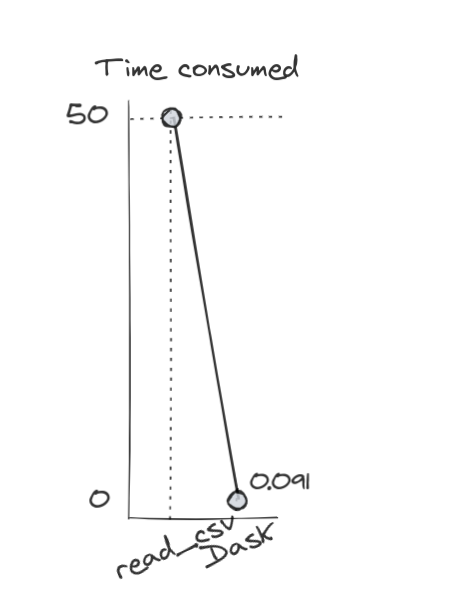



## Other Packages

There are other tools worth exploring depending on your workflow and performance needs.

* **Polars**: A fast DataFrame library built on Rust, designed for high-performance data processing. It supports lazy execution, parallelism, and efficient memory usage, making it a strong alternative to pandas for large datasets.

  * *Documentation*: [https://pola.rs/](https://pola.rs/)

* **RAPIDS**: A GPU-accelerated data science suite that lets you process and analyze data directly on GPUs. This can significantly speed up workloads by avoiding unnecessary data transfers between CPU and GPU.

  * *Documentation*: [https://docs.rapids.ai/](https://docs.rapids.ai/)

* **PySpark**: A must-know API for distributed data processing using Apache Spark. It allows you to scale your data workflows across clusters and handle very large datasets efficiently.

  * *Documentation*: [https://spark.apache.org/docs/latest/api/python/index.html](https://spark.apache.org/docs/latest/api/python/index.html)


### Here's a suggestion that could help,

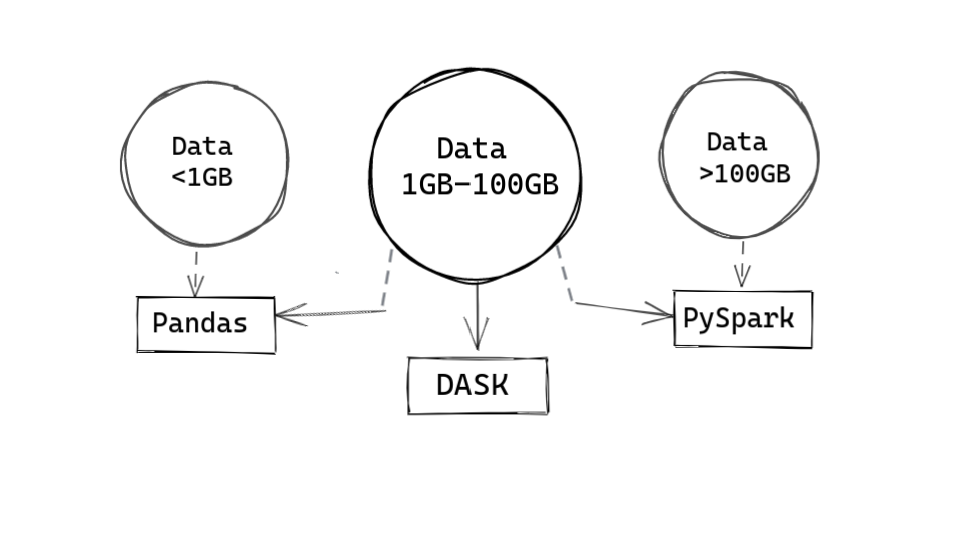